<h1>Regresión lineal 1D: Entrenamiento de dos parámetros</h1>


<h2>Objective</h2><ul><li> Cómo entrenar el modelo y visualizar los resultados de pérdidas.</li></ul> 


<h2>Tabla de contenido</h2>
<p>En este laboratorio, entrenarás un modelo con PyTorch usando los datos que creamos. El modelo tendrá la pendiente y el sesgo. Además, revisaremos cómo hacer predicciones de diferentes maneras usando PyTorch.</p>

<ul>
    <li><a href="#Make-Some-Data">Make Some Data</a></li>
    <li><a href="#Create-the-Model-and-Cost-Function-(Total-Loss)">Create the Model and Cost Function (Total Loss) </a></li>
    <li><a href="#Train-the-Model">Train the Model </a></li>
</ul>

<hr>


<h2>Preparation</h2>


We'll need the following libraries:  


In [1]:
# These are the libraries we are going to use in the lab.

# Importa la biblioteca NumPy, que es esencial para el cálculo numérico en Python,
# especialmente para trabajar con arreglos y matrices. Se le asigna el alias 'np'
# para un uso más corto y conveniente en el código.
import numpy as np

# Importa el módulo 'pyplot' de la biblioteca Matplotlib. Esta es una de las
# bibliotecas más populares para la creación de gráficos y visualizaciones en 2D,
# como líneas, dispersiones y barras. Se le asigna el alias 'plt' por convención.
import matplotlib.pyplot as plt

# Importa el kit de herramientas 'mplot3d' de Matplotlib. Este módulo en específico
# habilita la creación de gráficos en tres dimensiones. Es necesario para visualizar
# la superficie de pérdida, que tiene tres ejes: w, b y la pérdida (Z).
from mpl_toolkits import mplot3d

The class <code>plot_error_surfaces</code> is just to help you visualize the data space and the parameter space during training and has nothing to do with PyTorch. 


In [2]:
# The class for plot the diagram

class plot_error_surfaces(object):
    
    # Constructor
    # __init__ es el constructor de la clase. Se ejecuta al crear un objeto.
    # w_range y b_range: rangos para los valores de w y b en los gráficos.
    # X, Y: los datos de entrada y salida reales.
    # n_samples: número de puntos para la rejilla de los gráficos.
    # go: si es True, genera los gráficos iniciales de la superficie de error.
    def __init__(self, w_range, b_range, X, Y, n_samples = 30, go = True):
        # np.linspace crea un arreglo de valores espaciados uniformemente.
        # W y B son rangos de valores para la pendiente (w) y el sesgo (b).
        W = np.linspace(-w_range, w_range, n_samples)
        B = np.linspace(-b_range, b_range, n_samples)
        
        # np.meshgrid crea una rejilla de coordenadas a partir de los arreglos W y B.
        # Esto genera una matriz de w y b para cada combinación posible.
        w, b = np.meshgrid(W, B)    
        
        # Z es una matriz que contendrá los valores de pérdida (error) para cada par (w, b).
        # Se inicializa con ceros.
        Z = np.zeros((30,30))
        
        count1 = 0
        # Convierte los tensores de PyTorch X y Y a arreglos de NumPy para las operaciones.
        self.y = Y.numpy()
        self.x = X.numpy()
        
        # Bucle anidado para iterar sobre cada combinación de w y b de la rejilla.
        for w1, b1 in zip(w, b):
            count2 = 0
            for w2, b2 in zip(w1, b1):
                # Calcula el error cuadrático medio (MSE) para cada par (w, b).
                # (self.y - (w2 * self.x + b2)) es la diferencia entre los valores reales y predichos.
                # Se eleva al cuadrado y se promedia para obtener la pérdida.
                Z[count1, count2] = np.mean((self.y - (w2 * self.x + b2)) ** 2)
                count2 += 1
            count1 += 1
            
        # Almacena la matriz de pérdida Z y las matrices de coordenadas w y b como atributos de la clase.
        self.Z = Z
        self.w = w
        self.b = b
        
        # Inicializa listas vacías para almacenar los valores de w, b y la pérdida durante el entrenamiento.
        self.W = []
        self.B = []
        self.LOSS = []
        
        # n es un contador para las iteraciones de entrenamiento.
        self.n = 0
        
        # Si go es True, genera los gráficos iniciales de la superficie de pérdida.
        if go == True:
            # Crea una nueva figura para los gráficos.
            plt.figure()
            plt.figure(figsize = (7.5, 5))
            
            # Crea un eje 3D y grafica la superficie de pérdida.
            # La superficie muestra la pérdida para cada combinación de w y b.
            plt.axes(projection='3d').plot_surface(self.w, self.b, self.Z, rstride = 1, cstride = 1,cmap = 'viridis', edgecolor = 'none')
            
            # Añade títulos y etiquetas a los ejes.
            plt.title('Cost/Total Loss Surface')
            plt.xlabel('w')
            plt.ylabel('b')
            plt.show()
            
            # Crea una nueva figura para el gráfico de contorno.
            plt.figure()
            plt.title('Cost/Total Loss Surface Contour')
            plt.xlabel('w')
            plt.ylabel('b')
            
            # Grafica el contorno de la superficie de pérdida. Las líneas concéntricas
            # representan el mismo nivel de pérdida. El punto más bajo es el mínimo.
            plt.contour(self.w, self.b, self.Z)
            plt.show()
    
    # Setter
    # set_para_loss es un método para actualizar los parámetros de la clase durante el entrenamiento.
    # Almacena los valores de w, b y la pérdida en las listas correspondientes.
    def set_para_loss(self, W, B, loss):
        self.n = self.n + 1
        self.W.append(W)
        self.B.append(B)
        self.LOSS.append(loss)
    
    # Plot diagram
    # final_plot genera los gráficos finales después de que el entrenamiento ha terminado.
    def final_plot(self): 
        # Crea un gráfico 3D de "wireframe" de la superficie de pérdida.
        ax = plt.axes(projection = '3d')
        ax.plot_wireframe(self.w, self.b, self.Z)
        
        # Muestra los puntos (w, b, pérdida) que el algoritmo de descenso de gradiente
        # visitó durante el entrenamiento. Se muestran como "x" rojas.
        ax.scatter(self.W,self.B, self.LOSS, c = 'r', marker = 'x', s = 200, alpha = 1)
        
        # Crea un nuevo gráfico y muestra los puntos de la trayectoria del
        # entrenamiento en el contorno de la superficie de pérdida.
        plt.figure()
        plt.contour(self.w,self.b, self.Z)
        plt.scatter(self.W, self.B, c = 'r', marker = 'x')
        plt.xlabel('w')
        plt.ylabel('b')
        plt.show()
    
    # Plot diagram
    # plot_ps genera dos gráficos en la misma figura para ver la progresión
    # durante el entrenamiento.
    def plot_ps(self):
        # plt.subplot(121) crea el primer gráfico de una cuadrícula de 1 fila, 2 columnas.
        plt.subplot(121)
        plt.ylim
        
        # Grafica los puntos de datos originales.
        plt.plot(self.x, self.y, 'ro', label="training points")
        
        # Grafica la línea predicha por el modelo en la iteración actual, usando
        # los últimos valores de w y b almacenados.
        plt.plot(self.x, self.W[-1] * self.x + self.B[-1], label = "estimated line")
        
        plt.xlabel('x')
        plt.ylabel('y')
        plt.ylim((-10, 15))
        plt.title('Data Space Iteration: ' + str(self.n))

        # plt.subplot(122) crea el segundo gráfico.
        plt.subplot(122)
        
        # Grafica el contorno de la superficie de pérdida.
        plt.contour(self.w, self.b, self.Z)
        
        # Muestra los puntos (w, b) de las iteraciones de entrenamiento.
        plt.scatter(self.W, self.B, c = 'r', marker = 'x')
        plt.title('Total Loss Surface Contour Iteration' + str(self.n))
        plt.xlabel('w')
        plt.ylabel('b')
        plt.show()

<!--Empty Space for separating topics-->


<h2 id="Makeup_Data">Make Some Data</h2>


Import PyTorch: 


In [3]:
# Import PyTorch library

import torch

Start with generating values from -3 to 3 that create a line with a slope of 1 and a bias of -1. This is the line that you need to estimate.


In [4]:
# Create f(X) with a slope of 1 and a bias of -1

# Esta línea crea un tensor de PyTorch llamado 'X'.
# 'torch.arange(-3, 3, 0.1)' genera una secuencia de números que comienza en -3,
# termina justo antes de 3, y tiene un paso de 0.1. El resultado es un tensor 1D.
# '.view(-1, 1)' es un método que cambia la forma del tensor.
# El '-1' le dice a PyTorch que infiera automáticamente la cantidad de filas
# necesarias (en este caso, 60), y el '1' le indica que la nueva forma debe tener
# 1 columna. Esto es una práctica común para preparar los datos de entrada
# para modelos de PyTorch.
X = torch.arange(-3, 3, 0.1).view(-1, 1)

# Esta línea crea un tensor llamado 'f' que representa una línea recta perfecta.
# La ecuación de una línea es y = mx + b, donde m es la pendiente y b es el sesgo.
# Aquí, la pendiente es 1 (1 * X) y el sesgo es -1 (-1).
# Este tensor 'f' representa los datos de salida ideales, sin ningún ruido,
# que el modelo intentará aproximar durante el entrenamiento.
f = 1 * X - 1

Ahora, agregue algo de ruido a los datos:

In [5]:
# Agregar ruido
Y = f + 0.1 * torch.randn(X.size())

Plot the line and <code>Y</code> with noise:


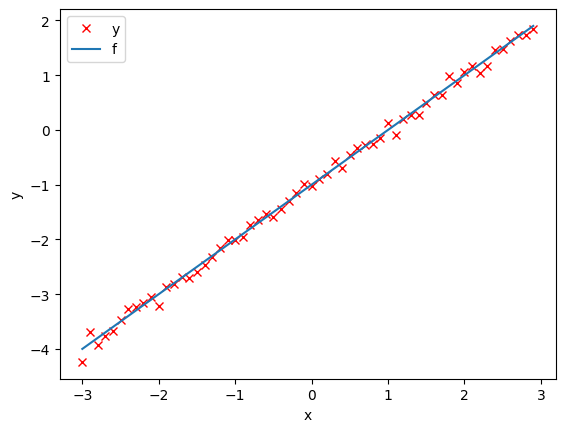

In [6]:
# Traza la línea y los puntos con ruido
plt.plot(X.numpy(), Y.numpy(), 'rx', label = 'y')
plt.plot(X.numpy(), f.numpy(), label = 'f')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

<h2 id="Model_Cost">Create the Model and Cost Function (Total Loss)</h2>


Define the <code>forward</code> function: 


In [8]:
# Define la función de avance (forward)

def forward(x):
    return w * x + b

Define the cost or criterion function (MSE): 


In [9]:
# Defina la función de pérdida de MSE

def criterion(yhat,y):
    return torch.mean((yhat-y)**2)

Create a <code> plot_error_surfaces</code> object to visualize the data space and the parameter space during training:


In [ ]:
# Crear plot_error_surfaces para visualizar los datos

get_surface = plot_error_surfaces(15, 15, X, Y, 30)

<!--Empty Space for separating topics-->


<h2 id="Train">Train the Model</h2>


Create model parameters <code>w</code>, <code>b</code> by setting the argument <code>requires_grad</code> to True because we must learn it using the data.


In [10]:
# Define los parámetros w, b para y = wx + b

# Crea un tensor de PyTorch llamado 'w' para representar el peso (slope) del modelo.
# Se inicializa con el valor -15.0.
# 'requires_grad = True' es un argumento fundamental. Le indica a PyTorch que debe
# rastrear todas las operaciones realizadas con este tensor para poder calcular
# automáticamente el gradiente de la pérdida con respecto a 'w' durante el
# 'backward pass'. Esto es esencial para el algoritmo de descenso de gradiente.
w = torch.tensor(-15.0, requires_grad = True)

# Crea un tensor de PyTorch llamado 'b' para representar el sesgo (bias o intercepto).
# Se inicializa con el valor -10.0.
# Al igual que con 'w', 'requires_grad = True' es necesario para que PyTorch
# pueda calcular el gradiente de la pérdida con respecto a 'b', permitiendo que
# este parámetro también se actualice durante el entrenamiento.
b = torch.tensor(-10.0, requires_grad = True)

Set the learning rate to 0.1 and create an empty list <code>LOSS</code> for storing the loss for each iteration.


In [12]:
# Define learning rate and create an empty list for containing the loss for each iteration.

# Define la tasa de aprendizaje (lr). Este es un hiperparámetro que controla
# qué tan grande es el paso que el algoritmo de descenso de gradiente toma
# en cada actualización de los parámetros. Un valor de 0.1 significa
# que los parámetros se ajustarán en un 10% de la magnitud del gradiente.
lr = 0.1

# Crea una lista vacía llamada 'LOSS'. Esta lista se usará para almacenar el
# valor de la pérdida (o error) del modelo después de cada iteración de
# entrenamiento. Al final del proceso, los valores en esta lista se pueden
# graficar para ver cómo el error disminuyó con el tiempo.
LOSS = []

Define <code>train_model</code> function for train the model.


In [13]:
# The function for training the model

# Define una función llamada train_model que toma un argumento 'iter'
# (número de iteraciones o épocas)
def train_model(iter):
    
    # Bucle que se ejecuta el número de veces especificado por 'iter'.
    # Cada repetición del bucle es una 'época' o una iteración de entrenamiento.
    for epoch in range(iter):
        
        # Paso 1: Forward Pass (Hacer una predicción)
        # Llama a la función 'forward' (que representa el modelo y = wx + b)
        # para predecir los valores de salida (Yhat) basándose en los datos de entrada X
        # y los valores actuales de w y b.
        Yhat = forward(X)
        
        # Paso 2: Calcular la pérdida
        # Llama a la función 'criterion' para calcular el error (loss) entre
        # los valores predichos (Yhat) y los valores reales (Y).
        loss = criterion(Yhat, Y)

        # Sección para la visualización (no parte del algoritmo principal)
        # Registra los valores de los parámetros y la pérdida para graficarlos.
        get_surface.set_para_loss(w.data.tolist(), b.data.tolist(), loss.tolist())
        
        # Cada 3 épocas, llama a la función para visualizar el progreso.
        if epoch % 3 == 0:
            get_surface.plot_ps()
            
        # Paso 3: Almacenar la pérdida
        # Agrega el valor de la pérdida de esta época a la lista 'LOSS'.
        # El '.append(loss)' es para hacer el seguimiento del error en cada iteración.
        LOSS.append(loss)
        
        # Paso 4: Backward Pass (Calcular gradientes)
        # Este es un paso clave de PyTorch. Calcula automáticamente el gradiente
        # de la 'loss' con respecto a todos los tensores que tienen 'requires_grad=True'
        # (en este caso, w y b). Los gradientes se almacenan en los atributos '.grad' de los tensores.
        loss.backward()
        
        # Paso 5: Actualizar los parámetros (descenso de gradiente)
        # Ajusta los parámetros w y b en la dirección opuesta a sus gradientes.
        # La fórmula es: nuevo_parámetro = parámetro_actual - (tasa_de_aprendizaje * gradiente).
        # Usar '.data' evita que PyTorch rastree estas operaciones en el gráfico de cómputo.
        w.data = w.data - lr * w.grad.data
        b.data = b.data - lr * b.grad.data
        
        # Paso 6: Reiniciar los gradientes a cero
        # Reinicia los gradientes a cero antes de la siguiente iteración. Esto es crucial
        # porque, por defecto, PyTorch acumula los gradientes en cada llamada a loss.backward().
        # Si no se reinician, los gradientes se sumarían en cada iteración, lo que llevaría
        # a un entrenamiento incorrecto.
        w.grad.data.zero_()
        b.grad.data.zero_()

Run 15 iterations of gradient descent: <b>bug</b> data space is 1 iteration ahead of parameter space 


<Figure size 640x480 with 0 Axes>

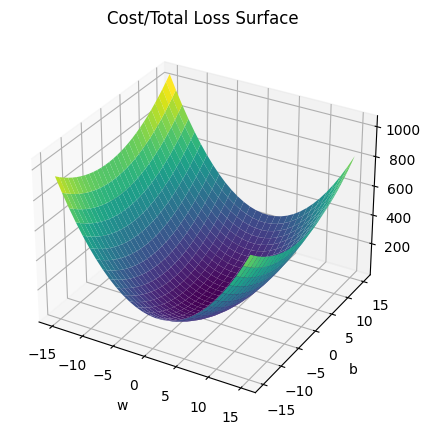

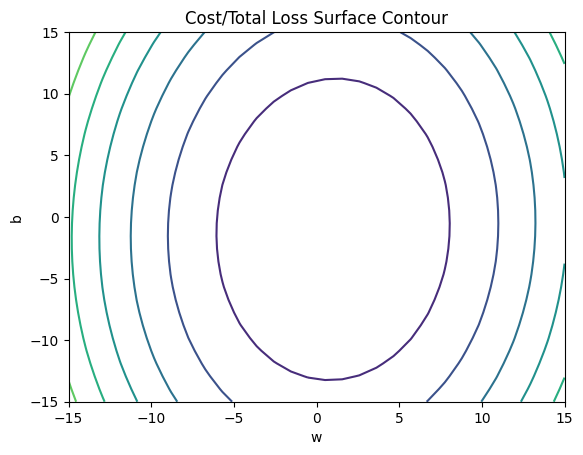

In [15]:
get_surface = plot_error_surfaces(15, 15, X, Y, 30)

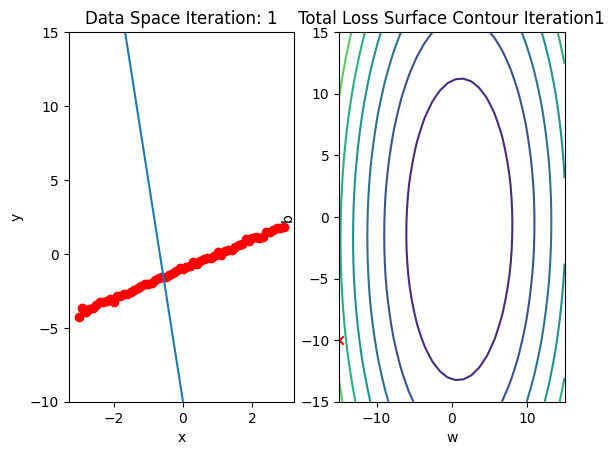

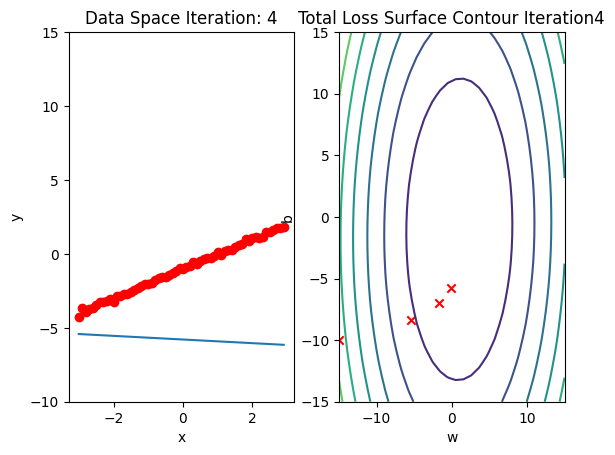

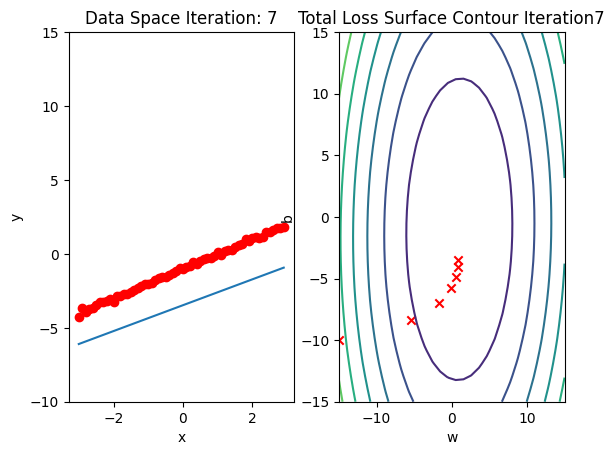

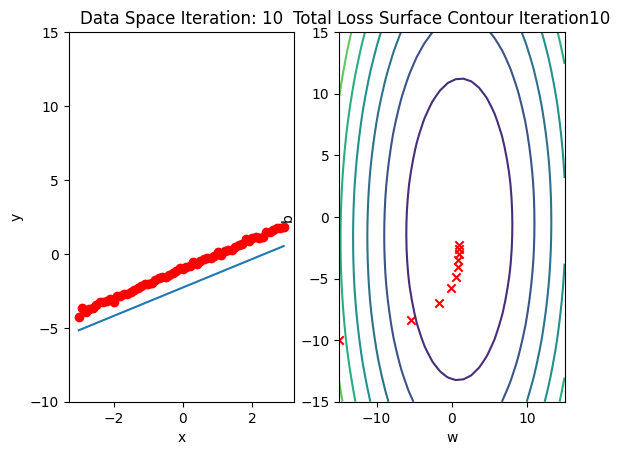

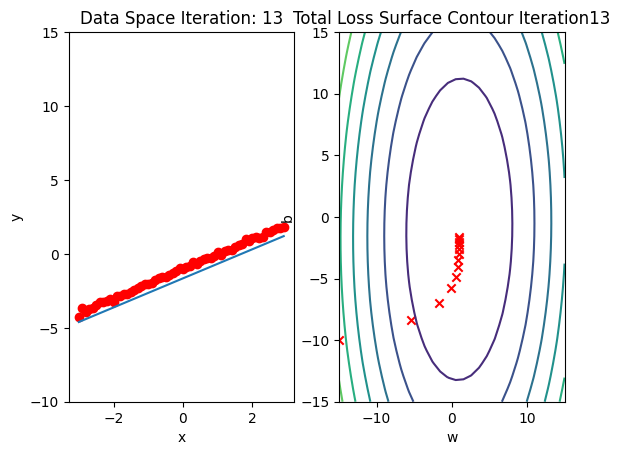

In [16]:
# Train the model with 15 iterations
# Esta línea llama a la función `train_model` que se definió previamente.
# El número 15 se pasa como argumento para el parámetro `iter`.
# Esto significa que la función ejecutará su bucle de entrenamiento
# exactamente 15 veces, lo que permitirá que el modelo ajuste sus
# parámetros (w y b) 15 veces para minimizar la pérdida.
train_model(15)

Plot total loss/cost surface with loss values for different parameters in red:


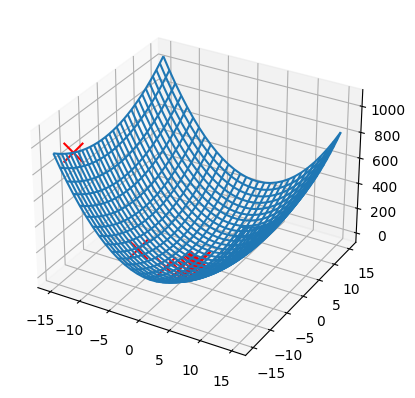

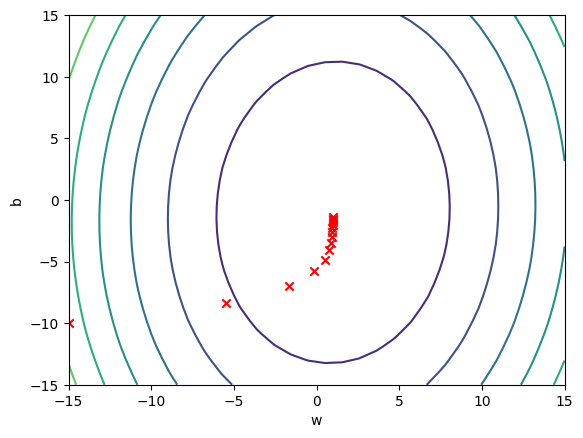

Text(38.347222222222214, 0.5, 'Cost')

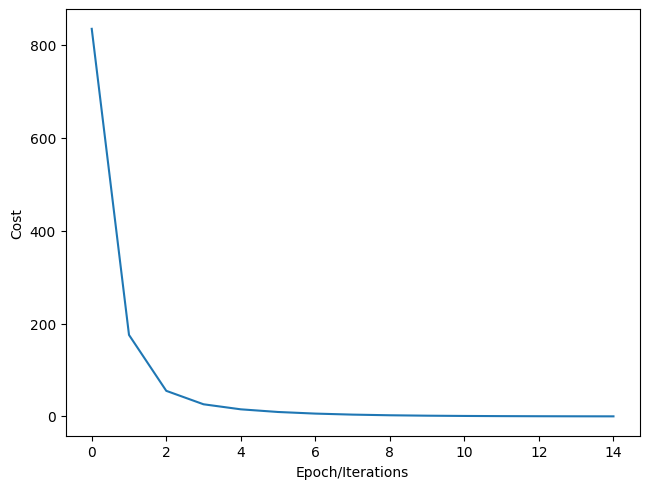

In [17]:
# Plot out the Loss Result

# Llama al método `final_plot` de la instancia `get_surface`.
# Este método genera una visualización final de la superficie de pérdida en 3D
# y el contorno 2D, mostrando la trayectoria de los parámetros `w` y `b` durante el entrenamiento.
get_surface.final_plot()

# Esta línea procesa la lista de tensores de pérdida llamada 'LOSS'.
# Primero, utiliza una comprensión de lista para iterar sobre cada tensor de pérdida.
# `.detach()` crea un nuevo tensor que no tiene historial de gradiente,
# lo que evita problemas al convertir el tensor a un tipo de dato diferente.
# `.numpy()` convierte el tensor de PyTorch a un array de NumPy, que es el formato
# que Matplotlib requiere para graficar. El resultado es una nueva lista llamada 'LOSS'
# que contiene los valores numéricos de la pérdida.
LOSS= [ loss.detach().numpy() for loss in LOSS]

# Utiliza Matplotlib para graficar la pérdida a lo largo de las iteraciones.
# La pérdida (eje y) se grafica en función de la época o iteración (eje x).
# Esto crea una curva que muestra cómo el error del modelo disminuyó durante el entrenamiento.
plt.plot(LOSS)

# Ajusta automáticamente los parámetros del gráfico para que todos los elementos
# quepan en la figura, evitando que las etiquetas se superpongan o se corten.
plt.tight_layout()

# Establece la etiqueta del eje x. "Epoch/Iterations" indica que este eje representa
# el número de épocas o iteraciones de entrenamiento.
plt.xlabel("Epoch/Iterations")

# Establece la etiqueta del eje y. "Cost" o "Costo" representa el valor de la
# función de pérdida o costo en cada iteración.
plt.ylabel("Cost")

<!--Empty Space for separating topics-->


<h3>Practice</h3>


Experiment using s learning rates 0.2 and width the following parameters. Run 15 iterations.


In [18]:
# Practice: train and plot the result with lr = 0.2 and the following parameters

# Inicializa el tensor 'w' (el peso o pendiente) con el valor -15.0.
# 'requires_grad=True' le indica a PyTorch que debe calcular y almacenar los gradientes
# para este tensor durante el entrenamiento, lo que permite su actualización.
w = torch.tensor(-15.0, requires_grad = True)

# Inicializa el tensor 'b' (el sesgo o intercepto) con el valor -10.0.
# Al igual que con 'w', 'requires_grad=True' es necesario para que el
# algoritmo de descenso de gradiente pueda actualizar este parámetro.
b = torch.tensor(-10.0, requires_grad = True)

# Redefine la tasa de aprendizaje. En este experimento, se usa un valor de 0.2,
# que es el doble que el anterior. Un valor más alto significa que los
# parámetros se ajustarán en pasos más grandes durante cada iteración.
lr = 0.2

# Crea una nueva lista vacía llamada 'LOSS2'. Esta lista almacenará los valores de
# la pérdida para este segundo experimento, permitiendo que se comparen
# con la lista 'LOSS' del primer entrenamiento.
LOSS2 = []

In [ ]:

def my_train_model(iter):
    for epoch in range(iter):
        Yhat = forward(X)
        loss = criterion(Yhat, Y)
        get_surface.set_para_loss(w.data.tolist(), b.data.tolist(), loss.tolist())
        if epoch % 3 == 0:
            get_surface.plot_ps()
        LOSS2.append(loss)
        loss.backward()
        w.data = w.data - lr * w.grad.data
        b.data = b.data - lr * b.grad.data
        w.grad.data.zero_()
        b.grad.data.zero_()
my_train_model(15)



Plot the <code>LOSS</code> and <code>LOSS2</code>


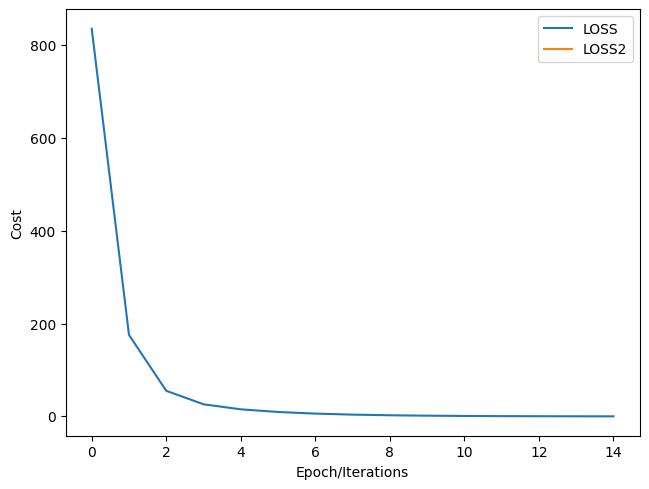

In [20]:
# Practice: Plot the LOSS and LOSS2 in order to compare the Total Loss

# Dibuja la curva de pérdida para el primer entrenamiento.
# 'LOSS' es la lista de valores de pérdida del primer modelo, entrenado con lr = 0.1.
# El argumento 'label' asigna un nombre a esta curva para la leyenda del gráfico.
plt.plot(LOSS, label = "LOSS")

# Dibuja la curva de pérdida para el segundo entrenamiento.
# 'LOSS2' es la lista de valores de pérdida del segundo modelo, entrenado con lr = 0.2.
# Su etiqueta la distinguirá de la primera línea en la leyenda.
plt.plot(LOSS2, label = "LOSS2")

# Ajusta el diseño del gráfico para que todos los elementos (títulos, etiquetas, leyenda)
# se adapten a la figura sin superponerse, lo que mejora la legibilidad.
plt.tight_layout()

# Establece la etiqueta para el eje X. "Epoch/Iterations" indica que este eje
# representa el progreso del entrenamiento a lo largo del tiempo.
plt.xlabel("Epoch/Iterations")

# Establece la etiqueta para el eje Y, que representa el valor de la
# función de costo o pérdida.
plt.ylabel("Cost")

# Muestra la leyenda del gráfico. Esta leyenda utiliza los 'label' que se definieron
# en las llamadas a `plt.plot()` para identificar cada curva. Es esencial para
# entender qué curva corresponde a cada experimento.
plt.legend()